In [2]:
import os
import platform
import lzma
import time
import resource
import multiprocessing
import kahypar as kahypar
import mtkahypar
import numpy as np
import psutil
import re
import json
from partitionsolver.utils import file_reader
import partitionsolver.utils.hypergraph_worker as hypergraph_worker
from matplotlib.style import context
import gc

from partitionsolver.utils import memory
from partitionsolver.utils import file_reader
from partitionsolver.utils import hypergraph_stats

from pysat.formula import CNF
from multiprocessing import Process, Queue



instances_small = "./instances/instances_small"
instances_medium = "./instances/instances_medium"
instances_big = "./instances/instances_big"
instances_large = "./instances/instances_large"


In [3]:
stats = hypergraph_stats.load_stats_file()

/tmp/ipykernel_2494/316217116.py:15: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 1)


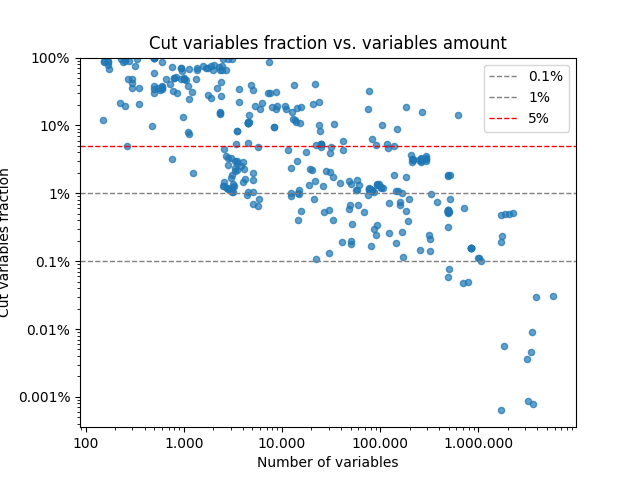

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplcursors
import pyperclip
%matplotlib widget

names = [name for name, stat in stats.items() if not stat["partition_error"]]
variables = [stat["num_vars"] for stat in stats.values() if not stat["partition_error"]]
percentages = [stat["cut"] / stat["num_vars"] for stat in stats.values() if not stat["partition_error"]]

fig, ax = plt.subplots()
scatter = ax.scatter(variables, percentages, alpha=0.7, s=20, picker=True, pickradius=5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(0, 1)
ax.set_xlabel("Number of variables")
ax.set_ylabel("Cut variables fraction")
ax.set_title("Cut variables fraction vs. variables amount")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", ".")))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x * 100:.3g}%".replace(",", ".")))
ax.axhline(y=0.001, color='gray', linestyle='--', linewidth=1, label='0.1%')
ax.axhline(y=0.01, color='gray', linestyle='--', linewidth=1, label='1%')
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1, label='5%')
ax.legend()

cursor = mplcursors.cursor(scatter, hover=True)

@cursor.connect("add")
def on_add(sel):
    sel.annotation.set_text(f"Variables: {variables[sel.index]}\nCut variables: {percentages[sel.index] * variables[sel.index]}\nName: {names[sel.index]}")
    sel.annotation.get_bbox_patch().set(fc="white", alpha=0.8)

def on_pick(event):
    if event.artist != scatter:
        return
    idx = event.ind[0]  # first point under the click, if multiple overlap
    pyperclip.copy(names[idx])
    print(f"Copied '{names[idx]}' to clipboard")

fig.canvas.mpl_connect('pick_event', on_pick)

plt.show()